In [1]:
import sys
print(sys.executable)

/Users/nicole/data-training/.venv/bin/python


In [2]:
import matplotlib.pyplot as plt
import plotly.express as px
import seaborn as sns 
import numpy as np
import json

In [4]:
# read bigquery data into pandas dataframe
import pandas as pd

rfm_df = pd.read_gbq(
    """
    SELECT  *
    FROM `jr-data-training.nicole.rfm`
    --- LIMIT 10
  """,
    project_id="jr-data-training",
)

df = pd.read_gbq(
    """
    SELECT  *
    FROM `jr-data-training.cafe.cafe-sales`
    --- LIMIT 10
  """,
    project_id="jr-data-training",
    location="australia-southeast1",
)

/var/folders/03/kg6152lx62g3z5rhmtm47_c80000gn/T/ipykernel_90450/2834326134.py:4: FutureWarning: read_gbq is deprecated and will be removed in a future version. Please use pandas_gbq.read_gbq instead: https://pandas-gbq.readthedocs.io/en/latest/api.html#pandas_gbq.read_gbq
  rfm_df = pd.read_gbq(
/var/folders/03/kg6152lx62g3z5rhmtm47_c80000gn/T/ipykernel_90450/2834326134.py:13: FutureWarning: read_gbq is deprecated and will be removed in a future version. Please use pandas_gbq.read_gbq instead: https://pandas-gbq.readthedocs.io/en/latest/api.html#pandas_gbq.read_gbq
  df = pd.read_gbq(


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 37372 entries, 0 to 37371
Data columns (total 8 columns):
 #   Column        Non-Null Count  Dtype         
---  ------        --------------  -----         
 0   order_id      37372 non-null  Int64         
 1   customer_id   37372 non-null  Int64         
 2   ip_addr       37372 non-null  object        
 3   date_created  37372 non-null  datetime64[us]
 4   date_paid     36019 non-null  datetime64[us]
 5   total         37372 non-null  Int64         
 6   status        37372 non-null  Int64         
 7   items         37372 non-null  object        
dtypes: Int64(4), datetime64[us](2), object(2)
memory usage: 2.4+ MB


In [37]:
order_df = df.groupby(df['date_created'].dt.date).size().reset_index(name='order_count')

full_date_range = pd.date_range(start=order_df['date_created'].min(),
                                end=order_df['date_created'].max(),
                                freq='D')

order_df = order_df.set_index('date_created').reindex(full_date_range).fillna(0).reset_index()
order_df = order_df.rename(columns={'index': 'date_created'})
order_df['order_count'] = order_df['order_count'].astype(int)


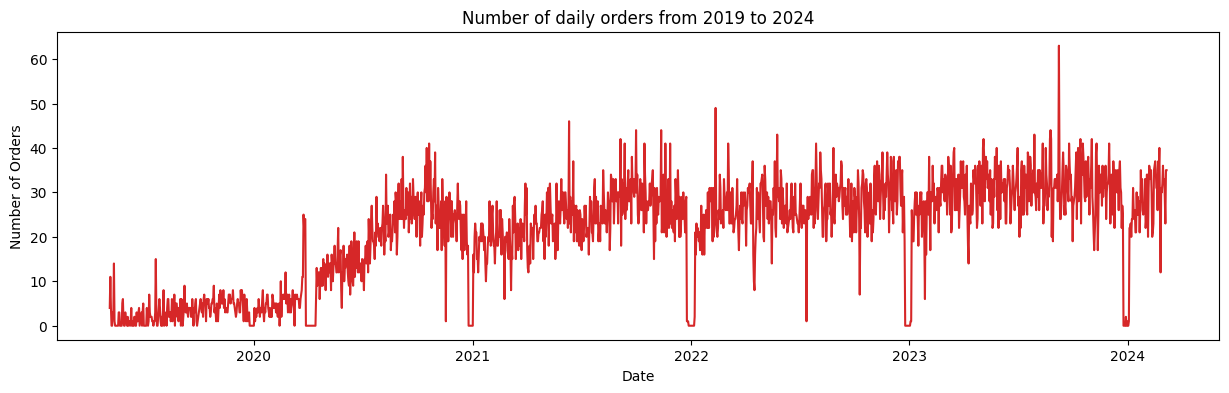

In [40]:
def plot_df(df, x, y, title="", xlabel='Date', ylabel='Number of Orders', dpi=100):
    plt.figure(figsize=(15,4), dpi=dpi)
    plt.plot(x, y, color='tab:red')
    plt.gca().set(title=title, xlabel=xlabel, ylabel=ylabel)
    plt.show()
    

plot_df(order_df, x=order_df['date_created'], y=order_df['order_count'], title='Number of daily orders from 2019 to 2024')

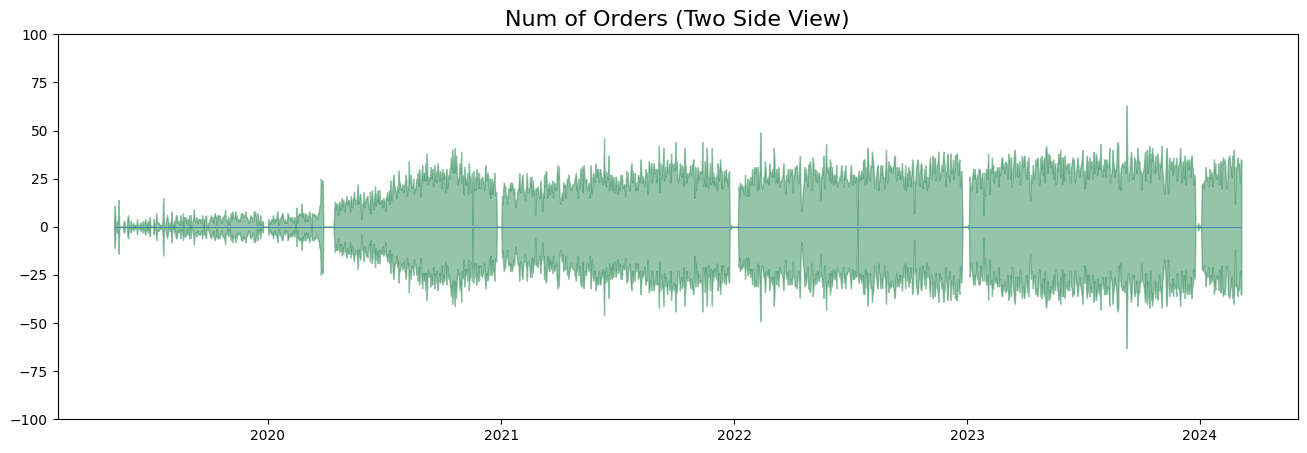

In [42]:
x = order_df['date_created'].values
y1 = order_df['order_count'].values

# Plot
fig, ax = plt.subplots(1, 1, figsize=(16,5))
plt.fill_between(x, y1=y1, y2=-y1, alpha=0.5, linewidth=1, color='seagreen')
plt.ylim(-100, 100)
plt.title('Num of Orders (Two Side View)', fontsize=16)
plt.hlines(y=0, xmin=np.min(order_df['date_created']), xmax=np.max(order_df['date_created']), linewidth=.5)
plt.show()